# Retrosheet → *The Book*, Recreated — Data Notebook

This notebook is the **data/back-end source of truth** for *The Book, Recreated*:
the project that rebuilds the run-expectancy tables from Tom Tango, Mitchel
Lichtman & Andrew Dolphin's *The Book* using real **Retrosheet** play-by-play data
(1980–2025). It has two jobs:

1. **Teach the pipeline** end to end — Retrosheet event files → Chadwick CSVs →
   additive JSON → the run-expectancy tables the website renders.
2. **Rebuild the datasets** the React site consumes.

## How to use it

| If you want to… | Do this |
|---|---|
| **Explore the numbers** (default) | Just **Run All**. Keep `RUN_PIPELINE = False` (§2). The existing JSON loads instantly and every section below renders a table and/or chart. |
| **Change what you see** | Use the **control panel in §12** — Seasons / League / Teams / Event. Every dashboard below it updates **live**; you do *not* need to re-run cells. |
| **Rebuild from Retrosheet** | Set `RUN_PIPELINE = True` in §2, then **Run All**. This downloads ~500 MB of event files and runs Chadwick `cwevent` (slow). |

> 📖 **First time?** Read top to bottom. Each section states the idea in markdown,
> shows the code, then the result — so the notebook doubles as a guided tour of how
> run expectancy is built from raw play-by-play.

## Map of the notebook

**Part A — The pipeline (how the data is made)**
- §1–§3 — setup, paths & run mode, local data inventory
- §4–§5 — the Retrosheet/Chadwick fields and the row-level translation helpers
- §6 — 🧮 the core run-expectancy idea on a toy half-inning
- §7–§10 — download/convert, the aggregators, and the rebuild orchestrator

**Part B — The analysis (what the data says) — 🎛️ interactive**
- §11–§13 — load the JSON, the **live control panel**, site-style aggregation
- §14 — run environment by season (the offensive era, at a glance)
- §15 — **Table 1**: run expectancy by base/out state — *plus a side-by-side with The Book's published figures*
- §16 — **Table 2**: runs to end of inning by event
- §17 — **Tables 3 & 4**: starting RE and run value
- §18 — **Table 5**: one event across all 24 base/out states
- §19–§20 — site sync checkpoint and the "add the next table" checklist

## 1. Imports and Display Setup

The notebook uses pandas for readable tables, matplotlib for charts, and ipywidgets for optional controls. The rebuild pipeline itself still uses mostly standard-library code so it can be debugged plainly.

In [1]:
from pathlib import Path
from collections import defaultdict
import csv
import json
import re
import shutil
import subprocess
import urllib.request
import zipfile

from IPython.display import Markdown, display
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd

# A consistent visual style for all generated notebook charts.
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

versions = pd.DataFrame(
    [
        
        ("pandas", pd.__version__),
        ("matplotlib", __import__("matplotlib").__version__),
        ("ipywidgets", widgets.__version__),
    ],
    columns=["Library", "Version"],
)

display(Markdown("**Notebook plotting/table dependencies loaded.**"))
display(versions)

**Notebook plotting/table dependencies loaded.**

,Library,Version
0,pandas,2.0.3
1,matplotlib,3.7.5
2,ipywidgets,8.1.8


## 2. Paths and Run Mode

The notebook can be launched from the repo root or from `Database/`. The paths below are resolved automatically.

Keep `RUN_PIPELINE = False` for fast exploration. Set it to `True` when you want to rebuild the source datasets.

In [2]:
CWD = Path.cwd().resolve()
DATABASE_DIR = CWD if CWD.name == "Database" else CWD / "Database"
if not DATABASE_DIR.exists():
    raise RuntimeError("Launch this notebook from the repo root or from Database/.")

REPO_ROOT = DATABASE_DIR.parent
RAW_DIR = DATABASE_DIR / "raw"
OUT_DIR = DATABASE_DIR / "out"
SITE_DATA_DIR = REPO_ROOT / "site" / "src" / "data"

# User choice: change these for a rebuild.
START_YEAR = 1980
END_YEAR = 2025
RUN_PIPELINE = False
COPY_TO_SITE = True
REMOVE_INTERMEDIATE_EVENTS = True
FORCE_DOWNLOAD = False
FORCE_CONVERT = True

OUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

path_table = pd.DataFrame(
    [
        ("Repository root", REPO_ROOT),
        ("Database folder", DATABASE_DIR),
        ("Raw Retrosheet cache", RAW_DIR),
        ("Generated data", OUT_DIR),
        ("Site data imports", SITE_DATA_DIR),
    ],
    columns=["Name", "Path"],
)

mode = "REBUILD MODE" if RUN_PIPELINE else "EXPLORER MODE"
display(Markdown(f"**Current mode:** `{mode}`"))
display(path_table)

**Current mode:** `EXPLORER MODE`

,Name,Path
0,Repository root,/Users/rexjensen/Desktop/Tango_book_recreation
1,Database folder,/Users/rexjensen/Desktop/Tango_book_recreation...
2,Raw Retrosheet cache,/Users/rexjensen/Desktop/Tango_book_recreation...
3,Generated data,/Users/rexjensen/Desktop/Tango_book_recreation...
4,Site data imports,/Users/rexjensen/Desktop/Tango_book_recreation...


## 3. What Data Is Already Available?

This cell confirms whether the generated JSON is present. If it is, the rest of the notebook can produce tables and charts without rebuilding the Retrosheet CSVs.

In [3]:
def human_size(path):
    """Return a compact file-size label for inventory tables."""
    if not path.exists():
        return "missing"
    size = path.stat().st_size
    for unit in ["B", "KB", "MB", "GB"]:
        if size < 1024 or unit == "GB":
            return f"{size:.1f} {unit}" if unit != "B" else f"{size} B"
        size /= 1024

inventory_rows = []
for name in ["re_dataset.json", "event_dataset.json", "event_states.json", "team_league_all.csv"]:
    path = OUT_DIR / name
    inventory_rows.append({"Artifact": name, "Exists": path.exists(), "Size": human_size(path)})

inventory_rows.extend([
    {"Artifact": "raw/<year>/ folders", "Exists": True, "Size": len([p for p in RAW_DIR.glob("[12][0-9][0-9][0-9]") if p.is_dir()])},
    {"Artifact": "out/events_<year>.csv", "Exists": True, "Size": len(list(OUT_DIR.glob("events_*.csv")))},
])

inventory = pd.DataFrame(inventory_rows)
display(Markdown("**Local data inventory**"))
display(inventory)

**Local data inventory**

,Artifact,Exists,Size
0,re_dataset.json,True,1.5 MB
1,event_dataset.json,True,1021.9 KB
2,event_states.json,True,5.1 MB
3,team_league_all.csv,True,15.4 KB
4,raw/<year>/ folders,True,46
5,out/events_<year>.csv,True,0


## 4. Retrosheet Fields and Baseball Constants

Chadwick's `cwevent` turns Retrosheet event files into CSV rows. The field list below is the contract between Retrosheet and this notebook.

The base states are encoded as bits:

- `1` = runner on first
- `2` = runner on second
- `4` = runner on third

So `7` means bases loaded (`1 + 2 + 4`).

In [4]:
CWEVENT_FIELDS = "0,1,2,3,4,8,9,26,27,28,34,35,38,40,48,58,59,60,61"
CWEVENT_HEADER = [
    "game_id", "vis_team", "inning", "bat_home", "outs", "vis_score", "home_score",
    "r1", "r2", "r3", "event_cd", "bat_event_fl", "sh_fl", "event_outs", "bunt_fl",
    "bat_dest", "r1_dest", "r2_dest", "r3_dest",
]

BASE_LABELS = {
    0: "_ _ _", 1: "1B _ _", 2: "_ 2B _", 4: "_ _ 3B",
    3: "1B 2B _", 5: "1B _ 3B", 6: "_ 2B 3B", 7: "1B 2B 3B",
}
BASE_ORDER = [0, 1, 2, 4, 3, 5, 6, 7]
OUTS = (0, 1, 2)

EVENT_CD = {
    23: "HR", 22: "3B", 21: "2B", 20: "1B",
    19: "FC", 18: "RBOE", 17: "INT", 16: "HBP",
    15: "IBB", 14: "NIBB", 13: "FLE", 11: "BK",
    10: "PB", 9: "WP", 8: "PK", 7: "PK",
    6: "CS", 5: "DI", 4: "SB", 3: "K",
}

CATS = [
    ("HR", "Home Run"), ("3B", "Triple"), ("2B", "Double"), ("RBOE", "Error"),
    ("INT", "Interference"), ("SAC", "Sac Bunt"), ("PB", "Passed Ball"),
    ("1B", "Single"), ("WP", "Wild Pitch"), ("HBP", "Hit by Pitch"),
    ("BK", "Balk"), ("NIBB", "Non-Intentional Walk"), ("IBB", "Intentional Walk"),
    ("SB", "Stolen Base"), ("DI", "Defensive Indifference"), ("BUNT", "Bunt"),
    ("PK", "Pickoff"), ("OUT", "Out (on Batted Ball)"), ("K", "Strikeout"),
    ("CS", "Caught Stealing"),
    ("FC", "Fielder's Choice"), ("FLE", "Foul Error"), ("OTHER", "Other"),
]
LABELS = dict(CATS)
CAT_ORDER = [key for key, _ in CATS]

fields_df = pd.DataFrame({"CSV column": range(len(CWEVENT_HEADER)), "Name": CWEVENT_HEADER})
events_df = pd.DataFrame(CATS, columns=["Code", "Display label"])

display(Markdown("**Chadwick CSV fields used by the pipeline**"))
display(fields_df)
display(Markdown("**Event categories used by the site**"))
display(events_df)

**Chadwick CSV fields used by the pipeline**

,CSV column,Name
0,0,game_id
1,1,vis_team
2,2,inning
3,3,bat_home
4,4,outs
5,5,vis_score
6,6,home_score
7,7,r1
8,8,r2
9,9,r3


**Event categories used by the site**

,Code,Display label
0,HR,Home Run
1,3B,Triple
2,2B,Double
3,RBOE,Error
4,INT,Interference
5,SAC,Sac Bunt
6,PB,Passed Ball
7,1B,Single
8,WP,Wild Pitch
9,HBP,Hit by Pitch


## 5. Row-Level Helpers

These helper functions translate a Retrosheet/Chadwick row into baseball concepts: runs scored on the play, starting base state, batting team, and event category.

The comments are intentionally explicit because most mistakes in this project would happen at this translation layer.

In [5]:
def scored(dest):
    """Return 1 if a batter/runner destination means that player scored."""
    try:
        # Chadwick destinations >= 4 mean the player crossed home plate.
        return 1 if int(dest) >= 4 else 0
    except ValueError:
        # Empty strings and non-numeric Retrosheet placeholders do not score.
        return 0


def runs_on_play(row):
    """Count every player who scored on this event."""
    return scored(row["bat_dest"]) + scored(row["r1_dest"]) + scored(row["r2_dest"]) + scored(row["r3_dest"])


def base_state(row):
    """Encode the starting base occupancy as a 3-bit number."""
    return (1 if row["r1"] else 0) | (2 if row["r2"] else 0) | (4 if row["r3"] else 0)


def batting_team(row):
    """Identify the team batting during the half-inning."""
    gid = row["game_id"]
    # Retrosheet game ids start with the home-team code, so gid[:3] is the home team.
    return gid[:3] if row["bat_home"] == "1" else row["vis_team"]


def state_key(base, outs):
    """Use the same compact base/out key shape as the React app."""
    return base * 10 + outs


def event_category(row):
    """Map Retrosheet EVENT_CD into the categories used in The Book tables."""
    cd = int(row["event_cd"])
    if cd == 2:
        # Generic outs are split because sacrifice bunts and bunt outs are analytically distinct.
        if row["sh_fl"] == "T":
            return "SAC"
        if row["bunt_fl"] == "T":
            return "BUNT"
        return "OUT"
    return EVENT_CD.get(cd, "OTHER")

sample_row = {
    "game_id": "SEA202504010", "vis_team": "BOS", "bat_home": "1",
    "r1": "runner_on_first", "r2": "", "r3": "runner_on_third",
    "event_cd": "23", "sh_fl": "F", "bunt_fl": "F",
    "bat_dest": "4", "r1_dest": "4", "r2_dest": "", "r3_dest": "4",
}

helper_demo = pd.DataFrame([
    ("runs_on_play", runs_on_play(sample_row)),
    ("base_state", f"{base_state(sample_row)} ({BASE_LABELS[base_state(sample_row)]})"),
    ("batting_team", batting_team(sample_row)),
    ("event_category", event_category(sample_row)),
], columns=["Helper", "Sample output"])

display(Markdown("**Helper functions loaded, with a home-run sample row**"))
display(helper_demo)

**Helper functions loaded, with a home-run sample row**

,Helper,Sample output
0,runs_on_play,3
1,base_state,5 (1B _ 3B)
2,batting_team,SEA
3,event_category,HR


## 6. 🧮 The Core Idea: Run Expectancy, on a Toy Half-Inning

Everything downstream rests on one number per play: **how many more runs the team
will score from here to the end of the inning.** For each play that is:

> `runs_to_end = (runs at inning start + total runs scored in the inning) − runs already scored before this play`

The chart below walks one made-up half-inning and shows that number ticking down
as outs accumulate. Then the big idea:

- **Run expectancy of a base/out state (Table 1)** = the *average* `runs_to_end`
  over the thousands of real plate appearances that began in that state.
- **Run value of an event (Tables 2–4)** = how much the average `runs_to_end`
  after the event exceeds the run expectancy of the state it started in.

So this toy inning is the whole project in miniature — §7 onward just runs the same
arithmetic over ~8 million real plays.

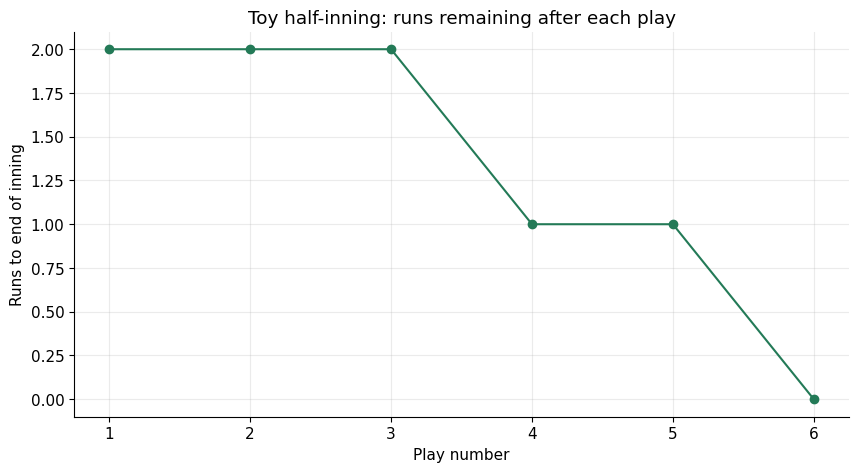

**Toy half-inning total runs:** `2`

,play,runs_before,runs_on_play,base/out start,runs_to_end
0,single,0,0,"empty, 0 out",2
1,walk,0,0,"man on 1st, 0 out",2
2,double,0,1,"1st+2nd, 0 out",2
3,groundout,1,0,"2nd+3rd, 0 out",1
4,sac fly,1,1,"2nd+3rd, 1 out",1
5,strikeout,2,0,"man on 2nd, 2 out",0


In [6]:
toy = pd.DataFrame([
    {"play": "single", "runs_before": 0, "runs_on_play": 0, "base/out start": "empty, 0 out"},
    {"play": "walk", "runs_before": 0, "runs_on_play": 0, "base/out start": "man on 1st, 0 out"},
    {"play": "double", "runs_before": 0, "runs_on_play": 1, "base/out start": "1st+2nd, 0 out"},
    {"play": "groundout", "runs_before": 1, "runs_on_play": 0, "base/out start": "2nd+3rd, 0 out"},
    {"play": "sac fly", "runs_before": 1, "runs_on_play": 1, "base/out start": "2nd+3rd, 1 out"},
    {"play": "strikeout", "runs_before": 2, "runs_on_play": 0, "base/out start": "man on 2nd, 2 out"},
])

inning_start_runs = 0
total_inning_runs = toy["runs_on_play"].sum()
toy["runs_to_end"] = inning_start_runs + total_inning_runs - toy["runs_before"]

fig, ax = plt.subplots()
ax.plot(toy.index + 1, toy["runs_to_end"], marker="o", color="#237a57")
ax.set_title("Toy half-inning: runs remaining after each play")
ax.set_xlabel("Play number")
ax.set_ylabel("Runs to end of inning")
ax.set_xticks(toy.index + 1)
plt.show()

display(Markdown(f"**Toy half-inning total runs:** `{total_inning_runs}`"))
display(toy)

## 7. Download and Convert Retrosheet Files

This is the extractor. It downloads missing Retrosheet yearly ZIPs, extracts `.EVA`/`.EVN` files, and converts them to `out/events_<year>.csv` with Chadwick.

This cell defines the functions but does not download anything until `build_all()` is called.

In [7]:
def ensure_cwevent():
    """Fail early if Chadwick is not installed."""
    if not shutil.which("cwevent"):
        raise RuntimeError("Chadwick is required. Install it with: brew install chadwick")


def season_event_files(year):
    """Return all Retrosheet event files for one season."""
    year_dir = RAW_DIR / str(year)
    return sorted(year_dir.glob(f"{year}*.EVA")) + sorted(year_dir.glob(f"{year}*.EVN"))


def download_and_extract_year(year, force=False):
    """Download a season ZIP from Retrosheet unless the extracted files already exist."""
    year_dir = RAW_DIR / str(year)
    year_dir.mkdir(parents=True, exist_ok=True)
    if season_event_files(year) and not force:
        return

    zip_path = year_dir / f"{year}eve.zip"
    url = f"https://www.retrosheet.org/events/{year}eve.zip"
    print(f"[{year}] downloading {url}")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(year_dir)
    zip_path.unlink(missing_ok=True)


def write_cwevent_csv(year, force=False):
    """Convert one season of Retrosheet event files into a flat CSV."""
    ensure_cwevent()
    out_path = OUT_DIR / f"events_{year}.csv"
    if out_path.exists() and not force:
        return out_path

    files = season_event_files(year)
    if not files:
        raise FileNotFoundError(f"No Retrosheet event files found for {year} in {RAW_DIR / str(year)}")

    year_dir = RAW_DIR / str(year)
    cmd = ["cwevent", "-y", str(year), "-f", CWEVENT_FIELDS] + [p.name for p in files]
    proc = subprocess.run(cmd, cwd=year_dir, text=True, capture_output=True)
    if proc.returncode != 0:
        print(proc.stderr.strip())
        raise RuntimeError(f"cwevent failed for {year} with exit code {proc.returncode}")

    with out_path.open("w", newline="") as f:
        writer = csv.writer(f, lineterminator="\n")
        writer.writerow(CWEVENT_HEADER)
        f.write(proc.stdout)
    return out_path


def team_league_rows_for_year(year):
    """The file extension tells us the home team's league for that season."""
    for path in sorted((RAW_DIR / str(year)).glob(f"{year}*.EVA")):
        yield [year, path.name[4:7], "AL"]
    for path in sorted((RAW_DIR / str(year)).glob(f"{year}*.EVN")):
        yield [year, path.name[4:7], "NL"]


def build_event_csvs(start_year=START_YEAR, end_year=END_YEAR, force_download=FORCE_DOWNLOAD, force_convert=FORCE_CONVERT):
    """Build all intermediate event CSVs plus the season/team league map."""
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    team_league_path = OUT_DIR / "team_league_all.csv"
    with team_league_path.open("w", newline="") as league_file:
        league_writer = csv.writer(league_file, lineterminator="\n")
        for year in range(start_year, end_year + 1):
            download_and_extract_year(year, force=force_download)
            csv_path = write_cwevent_csv(year, force=force_convert)
            league_writer.writerows(team_league_rows_for_year(year))
            event_count = sum(1 for _ in csv_path.open()) - 1
            print(f"[{year}] {event_count:,} converted events")
    return team_league_path

extractor_summary = pd.DataFrame([
    ("download_and_extract_year", "Gets missing Retrosheet ZIPs and extracts event files."),
    ("write_cwevent_csv", "Runs Chadwick cwevent and writes out/events_<year>.csv."),
    ("build_event_csvs", "Loops seasons and writes team_league_all.csv."),
], columns=["Function", "Purpose"])

display(Markdown("**Extractor functions are defined. No network/download work has run yet.**"))
display(extractor_summary)

**Extractor functions are defined. No network/download work has run yet.**

,Function,Purpose
0,download_and_extract_year,Gets missing Retrosheet ZIPs and extracts even...
1,write_cwevent_csv,Runs Chadwick cwevent and writes out/events_<y...
2,build_event_csvs,Loops seasons and writes team_league_all.csv.


## 8. Aggregator: Table 1 Run Expectancy

This cell defines the Table 1 builder. The important filters are:

- only complete half-innings ending with exactly three outs
- only plate appearances for Table 1
- additive output by `(season, team)` so the site can filter without reprocessing play-by-play

In [8]:
def load_team_league():
    """Load the season/team -> league lookup produced during extraction."""
    mapping = {}
    with (OUT_DIR / "team_league_all.csv").open() as f:
        for line in f:
            season, team, league = line.strip().split(",")
            mapping[(int(season), team)] = league
    return mapping


def event_csv_paths():
    """Find intermediate event CSVs currently available on disk."""
    return sorted(OUT_DIR.glob("events_*.csv"))


def season_from_events_path(path):
    """Extract the four-digit season from out/events_YYYY.csv."""
    return int(re.search(r"events_(\d{4})\.csv", path.name).group(1))


def process_re_season(path, season, groups, overall_by_season):
    """Accumulate Table 1 counts and run totals for one season."""
    rows = []
    inn_runs_start = {}
    inn_runs_total = defaultdict(int)
    inn_outs_total = defaultdict(int)

    with path.open(newline="") as f:
        for row in csv.DictReader(f):
            half = (row["game_id"], row["inning"], row["bat_home"])
            runs_before = int(row["vis_score"]) + int(row["home_score"])

            # The first row seen for a half-inning gives the score at inning start.
            if half not in inn_runs_start:
                inn_runs_start[half] = runs_before

            # These totals let us decide later whether the half-inning completed normally.
            inn_runs_total[half] += runs_on_play(row)
            inn_outs_total[half] += int(row["event_outs"])

            # Store just enough information to compute runs-to-end after inning totals are known.
            rows.append((half, runs_before, base_state(row), int(row["outs"]), row["bat_event_fl"] == "T", batting_team(row)))

    used_halves = set()
    for half, runs_before, base, outs, is_pa, team in rows:
        if inn_outs_total[half] != 3 or not is_pa:
            continue
        runs_roi = (inn_runs_start[half] + inn_runs_total[half]) - runs_before
        cell = (base, outs)
        groups[(season, team)][cell][0] += 1
        groups[(season, team)][cell][1] += runs_roi
        overall_by_season[season][cell][0] += 1
        overall_by_season[season][cell][1] += runs_roi
        used_halves.add(half)
    return len(used_halves)


def write_re_matrix(season, overall):
    """Write a human-readable 8x3 CSV for one season."""
    path = OUT_DIR / f"re_matrix_{season}.csv"
    with path.open("w", newline="") as f:
        writer = csv.writer(f, lineterminator="\n")
        writer.writerow(["bases", "0 outs", "1 out", "2 outs", "n_0", "n_1", "n_2"])
        for base in BASE_ORDER:
            vals, counts = [], []
            for outs in OUTS:
                count, sum_runs = overall[(base, outs)]
                vals.append(f"{sum_runs / count:.3f}" if count else "")
                counts.append(count)
            writer.writerow([BASE_LABELS[base]] + vals + counts)
    return path


def build_re_dataset():
    """Build Database/out/re_dataset.json for the site."""
    team_league = load_team_league()
    groups = defaultdict(lambda: defaultdict(lambda: [0, 0.0]))
    overall_by_season = defaultdict(lambda: defaultdict(lambda: [0, 0.0]))
    seasons = []

    for path in event_csv_paths():
        season = season_from_events_path(path)
        seasons.append(season)
        complete = process_re_season(path, season, groups, overall_by_season)
        count, sum_runs = overall_by_season[season][(0, 0)]
        print(f"{season}: {complete:,} complete innings, empty/0-out RE = {sum_runs / count:.3f}")
    seasons.sort()

    for season in seasons:
        write_re_matrix(season, overall_by_season[season])

    group_list = []
    for (season, team) in sorted(groups):
        cells = []
        for base in BASE_ORDER:
            for outs in OUTS:
                count, sum_runs = groups[(season, team)][(base, outs)]
                cells.append({"base": base, "outs": outs, "count": count, "sumRuns": round(sum_runs, 4)})
        group_list.append({"season": season, "team": team, "league": team_league.get((season, team), "?"), "cells": cells})

    dataset = {
        "meta": {
            "title": "Run Expectancy by the 24 Base/Out States",
            "source": "Retrosheet event files parsed with Chadwick cwevent, computed locally",
            "method": "mean runs scored to end of inning, per plate appearance; complete (3-out) innings only",
            "seasons": seasons,
            "baseLabels": {str(k): v for k, v in BASE_LABELS.items()},
            "baseOrder": BASE_ORDER,
        },
        "groups": group_list,
    }
    with (OUT_DIR / "re_dataset.json").open("w") as f:
        json.dump(dataset, f, separators=(",", ":"))
    return dataset

re_builder_summary = pd.DataFrame([
    ("Input", "out/events_<year>.csv"),
    ("Output", "out/re_dataset.json and out/re_matrix_<year>.csv"),
    ("Unit of additivity", "season + batting team + base/out state"),
    ("Main filter", "complete 3-out half-innings; plate appearances only"),
], columns=["Topic", "Value"])

display(Markdown("**Table 1 aggregator functions are defined.**"))
display(re_builder_summary)

**Table 1 aggregator functions are defined.**

,Topic,Value
0,Input,out/events_<year>.csv
1,Output,out/re_dataset.json and out/re_matrix_<year>.csv
2,Unit of additivity,season + batting team + base/out state
3,Main filter,complete 3-out half-innings; plate appearances...


## 9. Aggregator: Event Tables and Event Starting States

Tables 2-5 need event-level data. This cell builds two datasets:

- `event_dataset.json`: event -> count and runs-to-end totals
- `event_states.json`: event -> starting base/out distribution, which the site combines with Table 1 RE to calculate starting RE and run value

In [9]:
def process_event_season(path, season, groups):
    """Accumulate runs-to-end totals by event type for one season."""
    rows = []
    inn_runs_start = {}
    inn_runs_total = defaultdict(int)
    inn_outs_total = defaultdict(int)

    with path.open(newline="") as f:
        for row in csv.DictReader(f):
            half = (row["game_id"], row["inning"], row["bat_home"])
            runs_before = int(row["vis_score"]) + int(row["home_score"])
            if half not in inn_runs_start:
                inn_runs_start[half] = runs_before
            inn_runs_total[half] += runs_on_play(row)
            inn_outs_total[half] += int(row["event_outs"])
            rows.append((half, runs_before, event_category(row), batting_team(row)))

    for half, runs_before, cat, team in rows:
        if inn_outs_total[half] != 3:
            continue
        runs_roi = (inn_runs_start[half] + inn_runs_total[half]) - runs_before
        groups[(season, team)][cat][0] += 1
        groups[(season, team)][cat][1] += runs_roi


def write_event_table(season, totals):
    """Write a human-readable event table for one season."""
    path = OUT_DIR / f"re_by_event_{season}.csv"
    rows = []
    for cat in CAT_ORDER:
        count, sum_runs = totals.get(cat, (0, 0.0))
        if count:
            rows.append((LABELS[cat], cat, count, round(sum_runs, 1), sum_runs / count))
    rows.sort(key=lambda row: row[4], reverse=True)

    with path.open("w", newline="") as f:
        writer = csv.writer(f, lineterminator="\n")
        writer.writerow(["Event", "code", "N", "Runs to End of Inning", "Average Runs"])
        for label, cat, count, sum_runs, avg in rows:
            writer.writerow([label, cat, count, sum_runs, f"{avg:.3f}"])
    return path, rows


def build_event_dataset():
    """Build Database/out/event_dataset.json."""
    team_league = load_team_league()
    groups = defaultdict(lambda: defaultdict(lambda: [0, 0.0]))
    seasons = []
    for path in event_csv_paths():
        season = season_from_events_path(path)
        seasons.append(season)
        process_event_season(path, season, groups)
    seasons.sort()

    season_totals = defaultdict(lambda: defaultdict(lambda: [0, 0.0]))
    for (season, team), cats in groups.items():
        for cat, (count, sum_runs) in cats.items():
            season_totals[season][cat][0] += count
            season_totals[season][cat][1] += sum_runs
    for season in seasons:
        write_event_table(season, {key: tuple(value) for key, value in season_totals[season].items()})

    group_list = []
    for (season, team) in sorted(groups):
        cells = {cat: {"count": count, "sumRuns": round(sum_runs, 4)} for cat, (count, sum_runs) in groups[(season, team)].items()}
        group_list.append({"season": season, "team": team, "league": team_league.get((season, team), "?"), "cells": cells})

    dataset = {"meta": {"title": "Runs To End Of Inning, By Event", "source": "Retrosheet event files parsed with Chadwick cwevent, computed locally", "method": "mean runs scored to end of inning, over every occurrence of the event; complete (3-out) innings only", "seasons": seasons, "categories": CATS}, "groups": group_list}
    with (OUT_DIR / "event_dataset.json").open("w") as f:
        json.dump(dataset, f, separators=(",", ":"))
    return dataset


def process_event_state_season(path, season, groups):
    """Accumulate event totals split by starting base/out state."""
    rows = []
    inn_runs_start = {}
    inn_runs_total = defaultdict(int)
    inn_outs_total = defaultdict(int)

    with path.open(newline="") as f:
        for row in csv.DictReader(f):
            half = (row["game_id"], row["inning"], row["bat_home"])
            runs_before = int(row["vis_score"]) + int(row["home_score"])
            if half not in inn_runs_start:
                inn_runs_start[half] = runs_before
            inn_runs_total[half] += runs_on_play(row)
            inn_outs_total[half] += int(row["event_outs"])
            rows.append((half, runs_before, event_category(row), batting_team(row), state_key(base_state(row), int(row["outs"]))))

    for half, runs_before, cat, team, skey in rows:
        if inn_outs_total[half] != 3:
            continue
        runs_roi = (inn_runs_start[half] + inn_runs_total[half]) - runs_before
        event = groups[(season, team)][cat]
        event["count"] += 1
        event["sumRuns"] += runs_roi
        event["states"][skey][0] += 1
        event["states"][skey][1] += runs_roi


def build_event_states_dataset():
    """Build Database/out/event_states.json for Tables 2-6 on the site."""
    team_league = load_team_league()
    def new_event():
        return {"count": 0, "sumRuns": 0.0, "states": defaultdict(lambda: [0, 0])}

    groups = defaultdict(lambda: defaultdict(new_event))
    seasons = []
    for path in event_csv_paths():
        season = season_from_events_path(path)
        seasons.append(season)
        process_event_state_season(path, season, groups)
    seasons.sort()

    group_list = []
    for (season, team) in sorted(groups):
        events = {}
        for cat, event in groups[(season, team)].items():
            events[cat] = {"count": event["count"], "sumRuns": round(event["sumRuns"], 4), "states": {str(skey): [count, int(sum_runs)] for skey, (count, sum_runs) in sorted(event["states"].items())}}
        group_list.append({"season": season, "team": team, "league": team_league.get((season, team), "?"), "events": events})

    dataset = {"meta": {"title": "Starting Run Expectancy, By Event", "source": "Retrosheet event files parsed with Chadwick cwevent, computed locally", "method": "for every occurrence of an event, the run expectancy of the base/out state it started in (Table 1 matrix), averaged; complete (3-out) innings only", "seasons": seasons, "categories": CATS}, "groups": group_list}
    with (OUT_DIR / "event_states.json").open("w") as f:
        json.dump(dataset, f, separators=(",", ":"))
    return dataset

event_builder_summary = pd.DataFrame([
    ("event_dataset.json", "Table 2 standalone event averages"),
    ("event_states.json", "Tables 2-6 on the deployed site"),
    ("State payload", "[count, sumRuns] per event and starting base/out state"),
], columns=["Output", "Why it exists"])

display(Markdown("**Event aggregators are defined.**"))
display(event_builder_summary)

**Event aggregators are defined.**

,Output,Why it exists
0,event_dataset.json,Table 2 standalone event averages
1,event_states.json,Tables 2-6 on the deployed site
2,State payload,"[count, sumRuns] per event and starting base/o..."


## 10. Rebuild Orchestrator

This cell wires the extractor and aggregators together. If `RUN_PIPELINE` is `False`, it does nothing destructive and simply reports that the notebook is in Explorer mode.

In [10]:
def sync_site_data(files=("re_dataset.json", "event_states.json")):
    """Copy the generated JSON files the React site imports."""
    SITE_DATA_DIR.mkdir(parents=True, exist_ok=True)
    copied = []
    for name in files:
        src = OUT_DIR / name
        dst = SITE_DATA_DIR / name
        if not src.exists():
            raise FileNotFoundError(f"Cannot sync missing dataset: {src}")
        shutil.copy2(src, dst)
        copied.append(dst)
    return copied


def remove_intermediate_event_csvs():
    """Delete large regenerable event CSVs after JSON has been built."""
    removed = []
    for path in event_csv_paths():
        path.unlink()
        removed.append(path)
    return removed


def build_all(start_year=START_YEAR, end_year=END_YEAR, copy_to_site=COPY_TO_SITE, remove_intermediate_events=REMOVE_INTERMEDIATE_EVENTS, force_download=FORCE_DOWNLOAD, force_convert=FORCE_CONVERT):
    """Run the full Retrosheet -> JSON -> site-data pipeline."""
    build_event_csvs(start_year=start_year, end_year=end_year, force_download=force_download, force_convert=force_convert)
    re_data = build_re_dataset()
    event_data = build_event_dataset()
    state_data = build_event_states_dataset()
    copied = sync_site_data() if copy_to_site else []
    removed = remove_intermediate_event_csvs() if remove_intermediate_events else []
    return {"re_groups": len(re_data["groups"]), "event_groups": len(event_data["groups"]), "state_groups": len(state_data["groups"]), "copied": copied, "removed_csvs": len(removed)}

if RUN_PIPELINE:
    rebuild_result = build_all()
    rebuild_df = pd.DataFrame([(k, str(v)) for k, v in rebuild_result.items()], columns=["Result", "Value"])
    display(Markdown("**Rebuild complete.**"))
    display(rebuild_df)
else:
    rebuild_df = pd.DataFrame([
        ("Mode", "Explorer mode"),
        ("Action", "Skipped full Retrosheet rebuild"),
        ("To rebuild", "Set RUN_PIPELINE = True in section 2, then run all cells"),
    ], columns=["Setting", "Value"])
    display(Markdown("**Pipeline not run. Existing generated JSON will be used below.**"))
    display(rebuild_df)

**Pipeline not run. Existing generated JSON will be used below.**

,Setting,Value
0,Mode,Explorer mode
1,Action,Skipped full Retrosheet rebuild
2,To rebuild,"Set RUN_PIPELINE = True in section 2, then run..."


## 11. Load Generated JSON

Now we switch from pipeline code to analysis views. These are the tables and charts you should use to inspect the numbers before changing the site.

In [11]:
def read_json(name):
    """Load one generated dataset from Database/out."""
    path = OUT_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the notebook with RUN_PIPELINE = True first.")
    with path.open() as f:
        return json.load(f)

re_dataset = read_json("re_dataset.json")
event_dataset = read_json("event_dataset.json")
event_states = read_json("event_states.json")

loaded_summary = pd.DataFrame([
    ("re_dataset.json", len(re_dataset["groups"]), f"{min(re_dataset['meta']['seasons'])}-{max(re_dataset['meta']['seasons'])}"),
    ("event_dataset.json", len(event_dataset["groups"]), f"{min(event_dataset['meta']['seasons'])}-{max(event_dataset['meta']['seasons'])}"),
    ("event_states.json", len(event_states["groups"]), f"{min(event_states['meta']['seasons'])}-{max(event_states['meta']['seasons'])}"),
], columns=["Dataset", "(season, team) groups", "Seasons"])

display(Markdown("**Generated JSON loaded.**"))
display(loaded_summary)

**Generated JSON loaded.**

,Dataset,"(season, team) groups",Seasons
0,re_dataset.json,1318,1980-2025
1,event_dataset.json,1318,1980-2025
2,event_states.json,1318,1980-2025


## 12. 🎛️ Control Panel — drives every dashboard below

Set **Seasons / League / Teams / Event** here once. Every chart and table in
§15–§18 is wired to these controls with `ipywidgets.interactive_output`, so they
**re-render automatically** whenever you change a control — no manual cell reruns.

- **Teams** empty = all teams. Pick one or more to narrow to a franchise.
- **Event** only affects §18 (one event across all 24 states).
- **Reset filters** returns everything to the full 1980–2025 / all-teams / HR view.

> If your environment can't render widgets (e.g. a plain `nbconvert` run), the
> dashboards still execute once using the default selection, so you always see
> output.

In [12]:
all_seasons = tuple(re_dataset["meta"]["seasons"])
all_teams = sorted({group["team"] for group in re_dataset["groups"]})
all_events = [code for code, _ in CATS]

season_widget = widgets.SelectMultiple(options=all_seasons, value=all_seasons, description="Seasons", rows=10)
league_widget = widgets.Dropdown(options=["Both", "AL", "NL"], value="Both", description="League")
team_widget = widgets.SelectMultiple(options=all_teams, value=tuple(), description="Teams", rows=10)
event_widget = widgets.Dropdown(options=[(LABELS.get(code, code), code) for code in all_events], value="HR", description="Event")

reset_button = widgets.Button(description="Reset filters", icon="undo", button_style="warning")
def _reset_filters(_):
    season_widget.value = all_seasons
    league_widget.value = "Both"
    team_widget.value = tuple()
    event_widget.value = "HR"
reset_button.on_click(_reset_filters)

# One shared control set. Every dashboard below binds to these widgets through
# ipywidgets.interactive_output, so editing any control re-renders the charts
# live -- no need to re-run the analysis cells by hand.
CONTROLS = {"seasons": season_widget, "league": league_widget, "teams": team_widget}
CONTROLS_EVENT = dict(CONTROLS, event=event_widget)


def read_selection():
    """Live snapshot of the control panel as plain Python values."""
    seasons = set(season_widget.value) or set(all_seasons)
    league = league_widget.value
    teams = set(team_widget.value) if team_widget.value else None
    event = event_widget.value
    return seasons, league, teams, event


def normalize(seasons, teams):
    """Turn raw widget values (tuples) into the (set | None) shapes the helpers expect."""
    return (set(seasons) or set(all_seasons)), (set(teams) or None)


# Backwards-compatible alias; older cells called current_selection().
def current_selection(use_widgets=True):
    return read_selection()


panel = widgets.VBox([
    widgets.HTML("<b>Filters</b> &mdash; empty <i>Teams</i> means all teams. "
                 "Charts in &sect;15&ndash;&sect;18 update live as you change these."),
    widgets.HBox([season_widget, team_widget]),
    widgets.HBox([league_widget, event_widget]),
    reset_button,
])


def show_selection(seasons, league, teams, event):
    """Live readout of the current filter, re-rendered whenever a control changes."""
    seasons, teams = normalize(seasons, teams)
    df = pd.DataFrame([
        ("Seasons", f"{min(seasons)}-{max(seasons)} ({len(seasons)} of {len(all_seasons)})"),
        ("League", league),
        ("Teams", "All teams" if teams is None else ", ".join(sorted(teams))),
        ("Event (§18 only)", f"{event} - {LABELS.get(event, event)}"),
    ], columns=["Filter", "Current value"])
    display(df)

display(Markdown("**Interactive control panel.**"))
display(panel)
display(widgets.interactive_output(show_selection, CONTROLS_EVENT))

**Interactive control panel.**

Output()

## 13. Site-Style Aggregation Helpers

These functions mirror the React app: filter `(season, team)` groups, sum counts and run totals, and divide only at the end.

In [13]:
def group_matches(group, seasons=None, league="Both", teams=None):
    """Return whether one additive group belongs in the current selection."""
    if seasons is not None and group["season"] not in seasons:
        return False
    if league != "Both" and group.get("league") != league:
        return False
    if teams is not None and group["team"] not in teams:
        return False
    return True


def selection_label(seasons=None, league="Both", teams=None):
    """Human-readable label for tables and chart titles."""
    season_text = "all seasons" if seasons is None else f"{min(seasons)}-{max(seasons)}" if len(seasons) > 1 else str(next(iter(seasons)))
    team_text = "all teams" if teams is None else f"{len(teams)} teams"
    return f"{season_text}, {league}, {team_text}"


def compute_re_matrix_from_dataset(dataset, seasons=None, league="Both", teams=None):
    """Aggregate Table 1 cells for a selection."""
    matrix = {state_key(base, outs): {"base": base, "outs": outs, "count": 0, "sumRuns": 0.0, "re": None} for base in BASE_ORDER for outs in OUTS}
    for group in dataset["groups"]:
        if not group_matches(group, seasons, league, teams):
            continue
        for cell in group["cells"]:
            key = state_key(cell["base"], cell["outs"])
            matrix[key]["count"] += cell["count"]
            matrix[key]["sumRuns"] += cell["sumRuns"]
    for values in matrix.values():
        if values["count"]:
            values["re"] = values["sumRuns"] / values["count"]
    return matrix


def compute_event_totals(dataset, seasons=None, league="Both", teams=None):
    """Aggregate Table 2 event averages for a selection."""
    totals = defaultdict(lambda: {"count": 0, "sumRuns": 0.0})
    for group in dataset["groups"]:
        if not group_matches(group, seasons, league, teams):
            continue
        for cat, cell in group["cells"].items():
            totals[cat]["count"] += cell["count"]
            totals[cat]["sumRuns"] += cell["sumRuns"]
    rows = []
    for cat, values in totals.items():
        count = values["count"]
        avg = values["sumRuns"] / count if count else None
        rows.append({"cat": cat, "Event": LABELS.get(cat, cat), "N": count, "Average": avg})
    return pd.DataFrame(rows).sort_values("Average", ascending=False)

helper_summary = pd.DataFrame([
    ("group_matches", "Applies season/league/team filters."),
    ("compute_re_matrix_from_dataset", "Builds the Table 1 matrix for the chosen filters."),
    ("compute_event_totals", "Builds Table 2 event averages for the chosen filters."),
], columns=["Helper", "Purpose"])

display(Markdown("**Selection aggregation helpers loaded.**"))
display(helper_summary)

**Selection aggregation helpers loaded.**

,Helper,Purpose
0,group_matches,Applies season/league/team filters.
1,compute_re_matrix_from_dataset,Builds the Table 1 matrix for the chosen filters.
2,compute_event_totals,Builds Table 2 event averages for the chosen f...


## 14. Chart: Run Environment by Season

The empty-bases, zero-outs cell is the expected runs at the start of an inning. It is a compact proxy for the run environment.

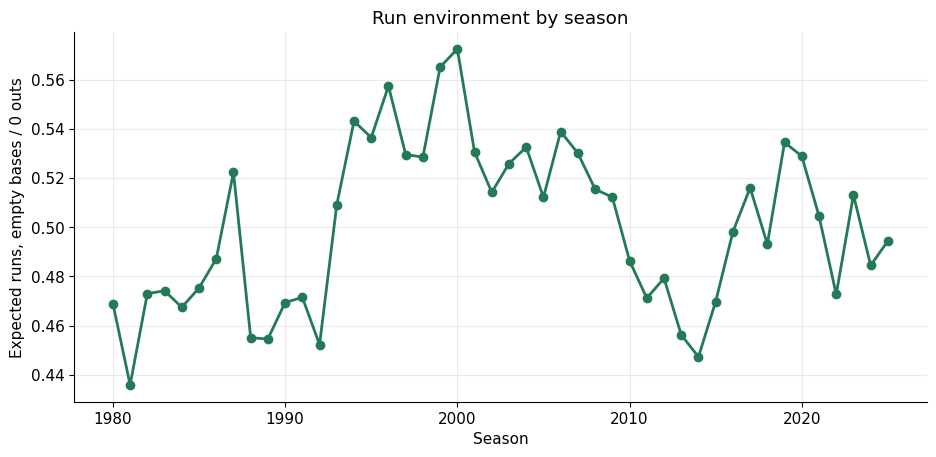

**Season-level run environment table**

,Season,Empty / 0 outs RE
36,2016,0.498168
37,2017,0.516118
38,2018,0.493153
39,2019,0.534636
40,2020,0.528999
41,2021,0.504595
42,2022,0.472663
43,2023,0.513184
44,2024,0.484473
45,2025,0.494504


In [14]:
season_points = []
for season in all_seasons:
    matrix = compute_re_matrix_from_dataset(re_dataset, seasons={season})
    season_points.append({"Season": season, "Empty / 0 outs RE": matrix[state_key(0, 0)]["re"]})
season_re_df = pd.DataFrame(season_points)

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(season_re_df["Season"], season_re_df["Empty / 0 outs RE"], color="#237a57", marker="o", linewidth=2)
ax.set_title("Run environment by season")
ax.set_xlabel("Season")
ax.set_ylabel("Expected runs, empty bases / 0 outs")
plt.show()

display(Markdown("**Season-level run environment table**"))
display(season_re_df.tail(10))

## 15. Table 1 — Run Expectancy by Base/Out State 🎛️

The 24-state matrix: the average number of runs scored from each base/out state to
the end of the inning. It should be **monotonic** — adding runners or removing outs
can only raise run expectancy — and the cell prints a quick sanity check that
confirms it for the current selection.

The second table puts our numbers **side by side with the figures published in
*The Book*** (computed from 1999–2002 data). Ours run a touch lower because
1999–2002 was a higher-offense era than most of the 1980–2025 window — narrow the
**Seasons** filter to 1999–2002 in §12 and watch the gap shrink.

In [15]:
# Run expectancy as published in The Book (Tango/Lichtman/Dolphin), 1999-2002 data.
# Keyed by base bitmask -> (0 out, 1 out, 2 out). Reference values for comparison only.
BOOK_1999_2002_RE = {
    0: (0.555, 0.297, 0.117),  # bases empty
    1: (0.953, 0.573, 0.251),  # 1B
    2: (1.189, 0.725, 0.344),  # 2B
    4: (1.482, 0.983, 0.387),  # 3B
    3: (1.573, 0.971, 0.466),  # 1B 2B
    5: (1.904, 1.243, 0.538),  # 1B 3B
    6: (2.052, 1.467, 0.634),  # 2B 3B
    7: (2.417, 1.650, 0.815),  # bases loaded
}


def render_table1(seasons, league, teams):
    """Heatmap + table of the 24-state run-expectancy matrix for the current filter."""
    seasons, teams = normalize(seasons, teams)
    matrix = compute_re_matrix_from_dataset(re_dataset, seasons, league, teams)

    out_cols = ["0 outs", "1 out", "2 outs"]
    re_rows = []
    for base in BASE_ORDER:
        row = {"Bases": BASE_LABELS[base]}
        for outs, col in zip(OUTS, out_cols):
            row[col] = matrix[state_key(base, outs)]["re"]
            row[f"N ({col})"] = matrix[state_key(base, outs)]["count"]
        re_rows.append(row)
    re_table = pd.DataFrame(re_rows)
    heat_values = re_table[out_cols]

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(heat_values, cmap="Greens", aspect="auto")
    ax.set_xticks(range(3), out_cols)
    ax.set_yticks(range(len(BASE_ORDER)), [BASE_LABELS[b] for b in BASE_ORDER])
    ax.set_title(f"Table 1 run expectancy — {selection_label(seasons, league, teams)}")
    for i in range(len(BASE_ORDER)):
        for j in range(3):
            value = heat_values.iloc[i, j]
            ax.text(j, i, "-" if pd.isna(value) else f"{value:.3f}", ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, label="Expected runs to end of inning")
    plt.show()

    # Sanity checks: RE must fall as outs rise, and the worst state must beat empty/0-out.
    re_of = lambda b, o: matrix[state_key(b, o)]["re"] or 0.0
    outs_monotonic = all(re_of(b, 0) >= re_of(b, 1) >= re_of(b, 2) for b in BASE_ORDER)
    loaded_beats_empty = re_of(7, 0) > re_of(0, 0)
    check = "✅" if (outs_monotonic and loaded_beats_empty) else "⚠️"
    display(Markdown(
        f"{check} **Sanity:** RE falls as outs rise in every row: `{outs_monotonic}` · "
        f"loaded/0-out beats empty/0-out: `{loaded_beats_empty}`"))
    display(re_table.round(3))


def render_book_compare(seasons, league, teams):
    """Compare each of the 24 cells against The Book's published 1999-2002 figures."""
    seasons, teams = normalize(seasons, teams)
    matrix = compute_re_matrix_from_dataset(re_dataset, seasons, league, teams)
    rows = []
    for base in BASE_ORDER:
        for outs in OUTS:
            ours = matrix[state_key(base, outs)]["re"]
            book = BOOK_1999_2002_RE[base][outs]
            rows.append({
                "Bases": BASE_LABELS[base],
                "Outs": outs,
                "This project": round(ours, 3) if ours is not None else None,
                "The Book ('99-'02)": book,
                "Diff": round(ours - book, 3) if ours is not None else None,
            })
    df = pd.DataFrame(rows)
    mean_gap = df["Diff"].dropna().mean()
    display(Markdown(
        f"Mean gap to *The Book* across the 24 states: **{mean_gap:+.3f}** runs/state "
        f"for {selection_label(seasons, league, teams)}. Negative ⇒ a lower-offense run "
        f"environment than 1999–2002."))
    display(df)

display(Markdown("Change any filter in §12 and both views below refresh automatically."))
display(widgets.interactive_output(render_table1, CONTROLS))
display(Markdown("**Our run expectancy vs. *The Book*'s published 1999–2002 matrix**"))
display(widgets.interactive_output(render_book_compare, CONTROLS))

Change any filter in §12 and both views below refresh automatically.

Output()

**Our run expectancy vs. *The Book*'s published 1999–2002 matrix**

Output()

## 16. Table 2: Runs to End of Inning by Event

This table is situational. It answers: after this event occurs, how many runs does the batting team score before the inning ends?

In [16]:
def render_table2(seasons, league, teams):
    """Table 2: average runs to end of inning, by event type, for the current filter."""
    seasons, teams = normalize(seasons, teams)
    event_avg_df = compute_event_totals(event_dataset, seasons, league, teams)
    book_event_df = event_avg_df[~event_avg_df["cat"].isin(["FC", "FLE", "OTHER"])].copy()

    fig, ax = plt.subplots(figsize=(10, 7))
    plot_df = book_event_df.head(18).sort_values("Average")
    ax.barh(plot_df["Event"], plot_df["Average"], color="#237a57")
    ax.set_title(f"Table 2 — runs to end of inning by event — {selection_label(seasons, league, teams)}")
    ax.set_xlabel("Average runs to end of inning")
    plt.show()

    display(Markdown("**Event averages (excluding not-in-book buckets), highest first**"))
    display(book_event_df.head(20)[["Event", "N", "Average"]].round(3))

display(widgets.interactive_output(render_table2, CONTROLS))

Output()

## 17. Tables 3 and 4: Starting RE and Run Value

Run value subtracts the run expectancy of the state where the event began:

`Run Value = Average Runs to End of Inning - Starting RE`

This is the table where events become values rather than just descriptions of their usual situations.

In [17]:
def compute_event_run_values(state_dataset, matrix, seasons=None, league="Both", teams=None):
    """Compute event average, starting RE, and run value for a selection."""
    totals = defaultdict(lambda: {"count": 0, "sumRuns": 0.0, "states": defaultdict(int)})
    for group in state_dataset["groups"]:
        if not group_matches(group, seasons, league, teams):
            continue
        for cat, event in group["events"].items():
            totals[cat]["count"] += event["count"]
            totals[cat]["sumRuns"] += event["sumRuns"]
            for skey, pair in event["states"].items():
                totals[cat]["states"][int(skey)] += pair[0]

    rows = []
    for cat, values in totals.items():
        count = values["count"]
        avg = values["sumRuns"] / count if count else None
        weighted_start = 0.0
        weighted_count = 0
        for skey, state_count in values["states"].items():
            re_value = matrix.get(skey, {}).get("re")
            if re_value is None:
                continue
            weighted_start += state_count * re_value
            weighted_count += state_count
        start_re = weighted_start / weighted_count if weighted_count else None
        rows.append({"cat": cat, "Event": LABELS.get(cat, cat), "N": count, "Average": avg, "Starting RE": start_re, "Run Value": avg - start_re if start_re is not None else None})
    return pd.DataFrame(rows).sort_values("Run Value", ascending=False)


def render_run_values(seasons, league, teams):
    """Tables 3 & 4: starting RE and run value (= Average - Starting RE) by event."""
    seasons, teams = normalize(seasons, teams)
    matrix = compute_re_matrix_from_dataset(re_dataset, seasons, league, teams)
    run_values_df = compute_event_run_values(event_states, matrix, seasons, league, teams)

    rv_plot_df = run_values_df[~run_values_df["cat"].isin(["FC", "FLE", "OTHER"])].copy()
    rv_plot_df = pd.concat([rv_plot_df.head(9), rv_plot_df.tail(8)]).sort_values("Run Value")

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ["#237a57" if v >= 0 else "#b34b4b" for v in rv_plot_df["Run Value"]]
    ax.barh(rv_plot_df["Event"], rv_plot_df["Run Value"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Table 4 — run value by event — {selection_label(seasons, league, teams)}")
    ax.set_xlabel("Runs above/below starting run expectancy")
    plt.show()

    display(Markdown("**Run value = Average − Starting RE, best to worst.** "
                     "Note the sacrifice bunt (`SAC`) is typically negative."))
    display(run_values_df[["Event", "N", "Average", "Starting RE", "Run Value"]].round(3).head(24))

display(widgets.interactive_output(render_run_values, CONTROLS))

Output()

## 18. Table 5: One Event Across All Base/Out States

This flips the view: choose one event, then inspect its run value across all 24 starting states.

In [18]:
def compute_state_event_rows(state_dataset, event_cat, matrix, seasons=None, league="Both", teams=None):
    """For one event, aggregate count/sumRuns by starting base/out state."""
    state_totals = {state_key(base, outs): {"count": 0, "sumRuns": 0.0} for base in BASE_ORDER for outs in OUTS}
    for group in state_dataset["groups"]:
        if not group_matches(group, seasons, league, teams):
            continue
        event = group["events"].get(event_cat)
        if not event:
            continue
        for skey, pair in event["states"].items():
            count, sum_runs = pair
            state_totals[int(skey)]["count"] += count
            state_totals[int(skey)]["sumRuns"] += sum_runs

    rows = []
    for base in BASE_ORDER:
        for outs in OUTS:
            skey = state_key(base, outs)
            count = state_totals[skey]["count"]
            avg = state_totals[skey]["sumRuns"] / count if count else None
            start_re = matrix[skey]["re"]
            run_value = avg - start_re if avg is not None and start_re is not None else None
            rows.append({"Bases": BASE_LABELS[base], "Outs": outs, "N": count, "Average": avg, "Starting RE": start_re, "Run Value": run_value})
    return pd.DataFrame(rows)


def render_state_event(seasons, league, teams, event):
    """Table 5: one event (set via the §12 Event control) across all 24 states."""
    seasons, teams = normalize(seasons, teams)
    matrix = compute_re_matrix_from_dataset(re_dataset, seasons, league, teams)
    state_event_df = compute_state_event_rows(event_states, event, matrix, seasons, league, teams)
    state_pivot = state_event_df.pivot(index="Bases", columns="Outs", values="Run Value").loc[[BASE_LABELS[b] for b in BASE_ORDER]]

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(state_pivot, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(3), ["0 outs", "1 out", "2 outs"])
    ax.set_yticks(range(len(state_pivot.index)), state_pivot.index)
    ax.set_title(f"{LABELS.get(event, event)} run value by starting state — {selection_label(seasons, league, teams)}")
    for i in range(state_pivot.shape[0]):
        for j in range(state_pivot.shape[1]):
            value = state_pivot.iloc[i, j]
            label = "-" if pd.isna(value) else f"{value:+.3f}"
            ax.text(j, i, label, ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, label="Run value")
    plt.show()

    display(Markdown(f"**Table 5 detail for `{event}` / {LABELS.get(event, event)}** "
                     "— pick a different **Event** in §12 to switch."))
    display(state_event_df.round(3))

display(Markdown("Set the **Event** control in §12 to choose which event this view breaks out."))
display(widgets.interactive_output(render_state_event, CONTROLS_EVENT))

Set the **Event** control in §12 to choose which event this view breaks out.

Output()

## 19. Site Sync Checkpoint

The site consumes `re_dataset.json` and `event_states.json` from `site/src/data/`. Use this cell when you have rebuilt data and want to copy without rerunning the full pipeline.

In [19]:
SITE_SYNC_NOW = False

if SITE_SYNC_NOW:
    copied = sync_site_data()
    sync_df = pd.DataFrame([(path.name, path) for path in copied], columns=["Copied file", "Destination"])
    display(Markdown("**Site data copied.**"))
    display(sync_df)
else:
    sync_df = pd.DataFrame([
        ("SITE_SYNC_NOW", SITE_SYNC_NOW),
        ("Action", "No files copied"),
        ("To copy", "Set SITE_SYNC_NOW = True and rerun this cell"),
    ], columns=["Setting", "Value"])
    display(Markdown("**Site sync skipped.**"))
    display(sync_df)

**Site sync skipped.**

,Setting,Value
0,SITE_SYNC_NOW,False
1,Action,No files copied
2,To copy,Set SITE_SYNC_NOW = True and rerun this cell


## 20. Adding the Next Table

Use this checklist when extending the project:

1. Add the new data computation in this notebook.
2. Explain the new statistic in markdown before the code.
3. Add comments where the calculation is easy to misunderstand.
4. Generate at least one DataFrame and one chart under the relevant cells.
5. Write additive JSON to `Database/out/` when site filters need to remain exact.
6. Copy site-consumed JSON into `site/src/data/`.
7. Add the React table under `site/src/tables/` and register it in `registry.js`.
8. Run `npm_config_cache=/tmp/npm-cache npm run build` from `site/`.

In [20]:
seasons, league, teams, event = read_selection()
completion = pd.DataFrame([
    ("Notebook mode", "Rebuild" if RUN_PIPELINE else "Explorer"),
    ("Current selection", selection_label(seasons, league, teams)),
    ("Selected event (§18)", f"{event} - {LABELS.get(event, event)}"),
    ("Dashboards", "§15–§18 react live to §12; Tables 1/2/4 follow Seasons/League/Teams, Table 5 also follows Event."),
    ("Next site check", "cd site && npm_config_cache=/tmp/npm-cache npm run build"),
], columns=["Item", "Value"])

display(Markdown("**Walkthrough complete.** Scroll back to §12 to re-slice everything live."))
display(completion)

**Walkthrough complete.** Scroll back to §12 to re-slice everything live.

,Item,Value
0,Notebook mode,Explorer
1,Current selection,"1980-2025, Both, all teams"
2,Selected event (§18),HR - Home Run
3,Dashboards,§15–§18 react live to §12; Tables 1/2/4 follow...
4,Next site check,cd site && npm_config_cache=/tmp/npm-cache npm...
